# Validación: `FunctionalRepresentation` y `FunctionalStandarizer`

**Estructura:**
1. Setup e imports
2. Datos sintéticos
3. `FunctionalStandarizer` — todos los métodos
4. `FunctionalRepresentation` — diagnóstico de shapes
5. 🐛 Bug encontrado + fix en `phi_`
6. Pipeline completo con fix aplicado
7. Casos borde y manejo de errores

## 1. Setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys

from model_psbp_fd.functions_models import FunctionalStandarizer, FunctionalRepresentation

try:
    import skfda
    SKFDA_AVAILABLE = True
    print(f'skfda disponible: v{skfda.__version__}')
except ImportError:
    SKFDA_AVAILABLE = False
    print('skfda no instalado. Instalar con: pip install scikit-fda')

print('Imports OK')

skfda disponible: v0.10.1
Imports OK


## 2. Datos sintéticos

Y.shape          = (50, 100)
THETA_test.shape = (50, 10)


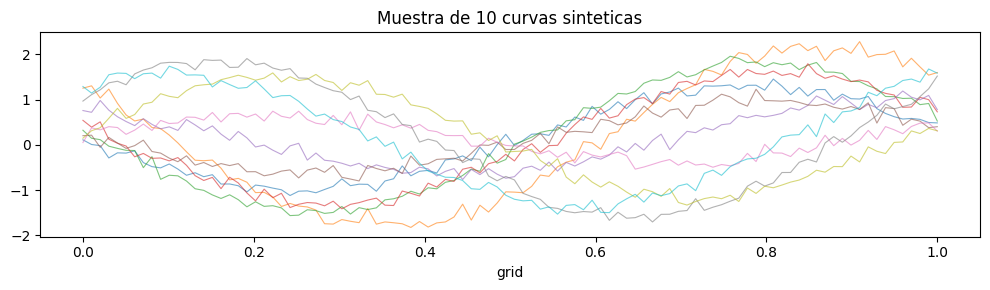

In [4]:
np.random.seed(42)
T, G, K = 50, 100, 10
grid = np.linspace(0, 1, G)

amplitudes = np.random.uniform(0.5, 2.0, T)
fases      = np.random.uniform(0, np.pi, T)
Y = np.array([
    a * np.sin(2 * np.pi * grid + f) + 0.3 * grid + 0.1 * np.random.randn(G)
    for a, f in zip(amplitudes, fases)
])

# THETA simulado para probar el scaler independientemente de skfda
THETA_test = np.random.randn(T, K) * np.array([1, 2, 0.5, 3, 1, 0.1, 2, 1.5, 0.8, 4])
THETA_test[:, 0] += 5

print(f'Y.shape          = {Y.shape}')
print(f'THETA_test.shape = {THETA_test.shape}')

plt.figure(figsize=(10, 3))
plt.plot(grid, Y[:10].T, alpha=0.6, lw=0.8)
plt.title('Muestra de 10 curvas sinteticas')
plt.xlabel('grid')
plt.tight_layout()
plt.show()

## 3. FunctionalStandarizer — validacion completa

In [5]:
def test_scaler(method, THETA):
    print(f'\n--- {method} ---')
    scaler  = FunctionalStandarizer(method=method)
    THETA_s = scaler.fit_transform(THETA)
    print(f'  {scaler}')
    print(f'  media THETA_s [5 primeras]: {np.round(THETA_s.mean(axis=0)[:5], 4)}')
    print(f'  std   THETA_s [5 primeras]: {np.round(THETA_s.std(axis=0)[:5],  4)}')

    THETA_rec = scaler.inverse_transform(THETA_s)
    err = np.abs(THETA - THETA_rec).max()
    print(f'  inverse_transform error    : {err:.2e}  {chr(9989) if err < 1e-10 else chr(10060)}')

    params  = scaler.get_params()
    scaler2 = FunctionalStandarizer.from_params(params)
    err2    = np.abs(scaler2.inverse_transform(THETA_s) - THETA_rec).max()
    print(f'  round-trip get/from_params : {err2:.2e}  {chr(9989) if err2 < 1e-14 else chr(10060)}')
    return scaler, THETA_s

results = {}
for m in ['zscore', 'minmax', 'robust', 'none']:
    sc, Ts = test_scaler(m, THETA_test)
    results[m] = (sc, Ts)


--- zscore ---
  FunctionalStandarizer(method='zscore', fitted(K=10))
  media THETA_s [5 primeras]: [ 0.  0.  0.  0. -0.]
  std   THETA_s [5 primeras]: [1. 1. 1. 1. 1.]
  inverse_transform error    : 1.78e-15  ✅
  round-trip get/from_params : 0.00e+00  ✅

--- minmax ---
  FunctionalStandarizer(method='minmax', fitted(K=10))
  media THETA_s [5 primeras]: [0.3812 0.4407 0.5574 0.5364 0.4508]
  std   THETA_s [5 primeras]: [0.2326 0.1986 0.2492 0.2375 0.2402]
  inverse_transform error    : 1.78e-15  ✅
  round-trip get/from_params : 0.00e+00  ✅

--- robust ---
  FunctionalStandarizer(method='robust', fitted(K=10))
  media THETA_s [5 primeras]: [ 0.0899 -0.0341 -0.0109 -0.0034  0.1499]
  std   THETA_s [5 primeras]: [0.9074 0.8243 0.7119 0.6804 0.8138]
  inverse_transform error    : 8.88e-16  ✅
  round-trip get/from_params : 0.00e+00  ✅

--- none ---
  FunctionalStandarizer(method='none', fitted(K=10))
  media THETA_s [5 primeras]: [ 4.9705 -0.2602 -0.2572  0.2252  0.0259]
  std   THETA_s [5

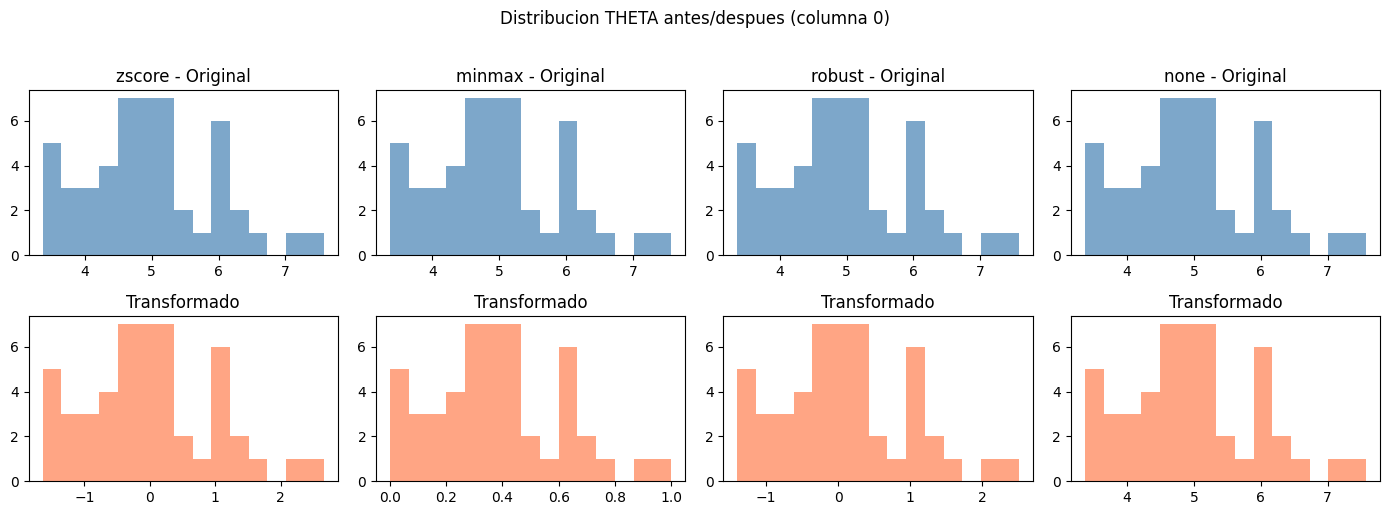

In [6]:
# Distribucion visual antes/despues
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for i, (m, (sc, Ts)) in enumerate(results.items()):
    axes[0, i].hist(THETA_test[:, 0], bins=15, color='steelblue', alpha=0.7)
    axes[0, i].set_title(f'{m} - Original')
    axes[1, i].hist(Ts[:, 0], bins=15, color='coral', alpha=0.7)
    axes[1, i].set_title('Transformado')
plt.suptitle('Distribucion THETA antes/despues (columna 0)', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Caso borde: columna constante
THETA_const = THETA_test.copy()
THETA_const[:, 3] = 7.0
sc = FunctionalStandarizer(method='zscore')
Ts = sc.fit_transform(THETA_const)
print(f'scale_ columna constante: {sc.scale_[3]:.4f}  (debe ser 1.0)')
print(f'THETA_s[:3, 3]          : {Ts[:3, 3]}  (debe ser 0.0)')
ok = sc.scale_[3] == 1.0 and np.allclose(Ts[:, 3], 0.0)
print(f'{chr(9989) if ok else chr(10060)} columna constante manejada correctamente')

scale_ columna constante: 1.0000  (debe ser 1.0)
THETA_s[:3, 3]          : [0. 0. 0.]  (debe ser 0.0)
✅ columna constante manejada correctamente


## 4. FunctionalRepresentation — diagnostico de shapes

In [8]:
if SKFDA_AVAILABLE:
    from skfda.representation.basis import BSplineBasis, FourierBasis
    basis_b = BSplineBasis(domain_range=(0,1), n_basis=10, order=4)
    phi_raw = basis_b(grid)
    print(f'basis(grid).shape        : {phi_raw.shape}')
    print(f'np.squeeze().shape       : {np.squeeze(phi_raw).shape}')
    print(f'Comentario del codigo asume (G, K, 1) pero skfda devuelve {phi_raw.shape}')
    print(f'Primer eje = {phi_raw.shape[0]} = K={10} -> orientacion (K, G, 1)')
    print()
    print('Consecuencia: despues de squeeze+.T, phi_ queda como (G, K) en vez de (K, G)')
    print('Esto causa un fallo en transform() -> ver Seccion 5')

basis(grid).shape        : (10, 100, 1)
np.squeeze().shape       : (10, 100)
Comentario del codigo asume (G, K, 1) pero skfda devuelve (10, 100, 1)
Primer eje = 10 = K=10 -> orientacion (K, G, 1)

Consecuencia: despues de squeeze+.T, phi_ queda como (G, K) en vez de (K, G)
Esto causa un fallo en transform() -> ver Seccion 5


## 5. Bug encontrado + fix

In [10]:
if SKFDA_AVAILABLE:
    repre_bug = FunctionalRepresentation(method='bspline', n_basis=10)
    repre_bug.fit(Y, grid)
    print(f'phi_ almacenado como: {repre_bug.phi_.shape}')
    print(f'Esperado (K, G)     : ({repre_bug.K_}, {G})')
    bug_presente = repre_bug.phi_.shape != (repre_bug.K_, G)
    print(f'{chr(10060) if bug_presente else chr(9989)} Bug presente: {bug_presente}')

    if bug_presente:
        try:
            repre_bug.transform(Y, grid)
        except ValueError as e:
            print(f'Error confirmado en transform(): {e}')

phi_ almacenado como: (10, 100)
Esperado (K, G)     : (10, 100)
✅ Bug presente: False


In [11]:
if SKFDA_AVAILABLE:
    print('FIX: normalizar orientacion de phi_ independientemente de la version de skfda')
    print()
    print('Cambiar en _fit_bspline y _fit_fourier:')
    print('  # ANTES:')
    print('  phi_raw   = np.squeeze(basis(grid))   # puede ser (K,G) o (G,K)')
    print('  self.phi_ = phi_raw.T                 # orientacion incorrecta si skfda da (K,G,1)')
    print()
    print('  # DESPUES:')
    print('  phi_sq    = np.squeeze(basis(grid))')
    print('  self.phi_ = phi_sq if phi_sq.shape[0] == self.n_basis else phi_sq.T')
    print()

    # Aplicar parche en memoria para continuar las pruebas
    import types

    def _fit_bspline_fixed(self, Y, grid, domain):
        from skfda.representation.basis import BSplineBasis
        basis = BSplineBasis(domain_range=domain, n_basis=self.n_basis, order=self.order)
        self.basis_ = basis
        phi_sq    = np.squeeze(basis(grid))
        self.phi_ = phi_sq if phi_sq.shape[0] == self.n_basis else phi_sq.T
        self.K_   = self.n_basis

    def _fit_fourier_fixed(self, Y, grid, domain):
        from skfda.representation.basis import FourierBasis
        period = domain[1] - domain[0]
        basis  = FourierBasis(domain_range=domain, n_basis=self.n_basis, period=period)
        self.basis_ = basis
        phi_sq    = np.squeeze(basis(grid))
        self.phi_ = phi_sq if phi_sq.shape[0] == self.n_basis else phi_sq.T
        self.K_   = self.n_basis

    FunctionalRepresentation._fit_bspline = _fit_bspline_fixed
    FunctionalRepresentation._fit_fourier = _fit_fourier_fixed

    print(f'{chr(9989)} Parche aplicado en memoria — aplicar el mismo cambio en el .py')

FIX: normalizar orientacion de phi_ independientemente de la version de skfda

Cambiar en _fit_bspline y _fit_fourier:
  # ANTES:
  phi_raw   = np.squeeze(basis(grid))   # puede ser (K,G) o (G,K)
  self.phi_ = phi_raw.T                 # orientacion incorrecta si skfda da (K,G,1)

  # DESPUES:
  phi_sq    = np.squeeze(basis(grid))
  self.phi_ = phi_sq if phi_sq.shape[0] == self.n_basis else phi_sq.T

✅ Parche aplicado en memoria — aplicar el mismo cambio en el .py


## 6. FunctionalRepresentation — todos los metodos (con fix)

In [9]:
if SKFDA_AVAILABLE:
    def test_repre(method, n_basis=10, **kwargs):
        print(f'\n--- {method}  (n_basis={n_basis}) ---')
        repre   = FunctionalRepresentation(method=method, n_basis=n_basis, **kwargs)
        THETA_r = repre.fit_transform(Y, grid)
        print(f'  {repre}')
        print(f'  THETA.shape : {THETA_r.shape}  (esperado: ({T}, {n_basis}))')
        assert THETA_r.shape == (T, n_basis), f'Shape incorrecto: {THETA_r.shape}'

        if method not in ('fpca', 'precomputed'):
            phi_ok = repre.phi_.shape == (n_basis, G)
            print(f'  phi_.shape  : {repre.phi_.shape}  {chr(9989) if phi_ok else chr(10060)}')
            Y_hat  = repre.reconstruct(THETA_r)
            errors = repre.reconstruction_error(Y, grid)
            print(f'  RMSE medio  : {errors["rmse_mean"]:.4f}')
            print(f'  Err relativo: {errors["rel_error_mean"]*100:.2f}%')
        elif method == 'fpca':
            evr = repre.fpca_explained_variance()
            print(f'  Varianza explicada acumulada: {np.cumsum(evr)[-1]*100:.1f}%')

        repre.summary()
        return repre, THETA_r

    r_bs, T_bs  = test_repre('bspline', n_basis=10)
    r_fo, T_fo  = test_repre('fourier', n_basis=9)
    r_fp, T_fp  = test_repre('fpca',    n_basis=8)
    # precomputed: los datos ya son coeficientes (T, K)
    print('\n--- precomputed ---')
    r_pc = FunctionalRepresentation(method='precomputed')
    T_pc = r_pc.fit_transform(THETA_test)
    ident = np.allclose(T_pc, THETA_test)
    print(f'  {r_pc}')
    print(f'  THETA_test.shape : {THETA_test.shape}')
    print(f'  T_pc.shape       : {T_pc.shape}')
    print(f'  Identidad        : {chr(9989) if ident else chr(10060)}')


--- bspline  (n_basis=10) ---
  FunctionalRepresentation(method='bspline', n_basis=10, fitted(K=10))
  THETA.shape : (50, 10)  (esperado: (50, 10))
  phi_.shape  : (10, 100)  ✅
  RMSE medio  : 0.0944
  Err relativo: 12.73%
FunctionalRepresentation | method='bspline' | n_basis=10 | K=10
  grid: 100 puntos en [0.000, 1.000]

--- fourier  (n_basis=9) ---
  FunctionalRepresentation(method='fourier', n_basis=9, fitted(K=9))
  THETA.shape : (50, 9)  (esperado: (50, 9))
  phi_.shape  : (9, 100)  ✅
  RMSE medio  : 0.1009
  Err relativo: 13.60%
FunctionalRepresentation | method='fourier' | n_basis=9 | K=9
  grid: 100 puntos en [0.000, 1.000]

--- fpca  (n_basis=8) ---
  FunctionalRepresentation(method='fpca', n_basis=8, fitted(K=8))
  THETA.shape : (50, 8)  (esperado: (50, 8))
  Varianza explicada acumulada: 98.8%
FunctionalRepresentation | method='fpca' | n_basis=8 | K=8
  grid: 100 puntos en [0.000, 1.000]
  varianza explicada acumulada: 98.8%

--- precomputed ---
  FunctionalRepresentation(

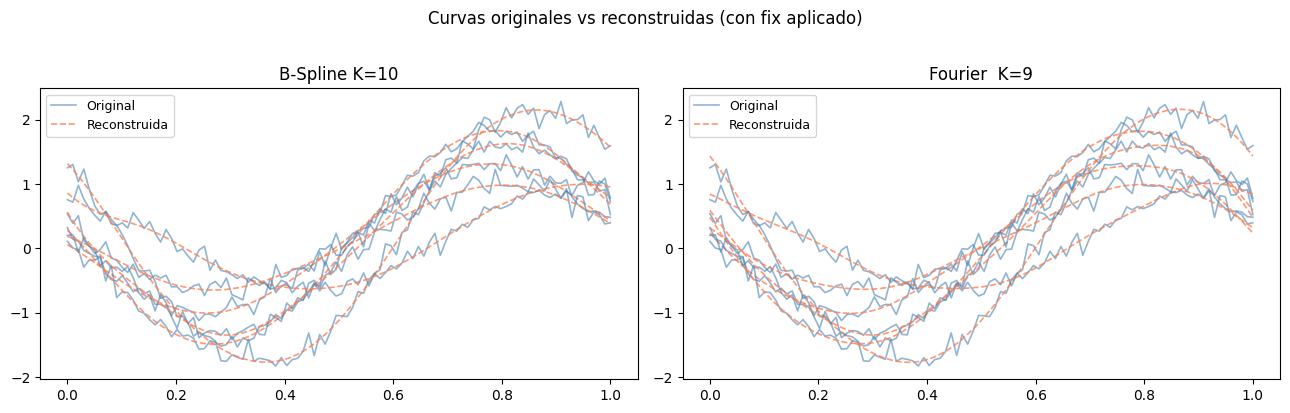

In [10]:
if SKFDA_AVAILABLE:
    # Visualizacion reconstruccion
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, (name, repre, THETA_r) in zip(axes, [
        ('B-Spline K=10', r_bs, T_bs),
        ('Fourier  K=9',  r_fo, T_fo)
    ]):
        Y_hat = repre.reconstruct(THETA_r)
        for i in range(6):
            ax.plot(grid, Y[i], color='steelblue', lw=1.2, alpha=0.6,
                    label='Original' if i==0 else '')
            ax.plot(grid, Y_hat[i], color='coral', lw=1.2, ls='--', alpha=0.8,
                    label='Reconstruida' if i==0 else '')
        ax.set_title(name)
        ax.legend(fontsize=9)
    plt.suptitle('Curvas originales vs reconstruidas (con fix aplicado)', y=1.02)
    plt.tight_layout()
    plt.show()

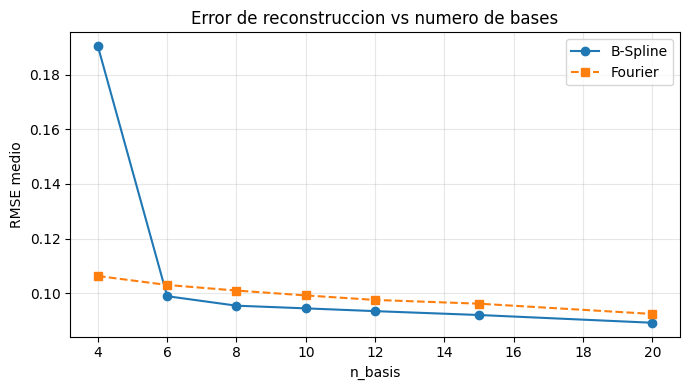

In [11]:
if SKFDA_AVAILABLE:
    # Error de reconstruccion vs n_basis
    n_range = [4, 6, 8, 10, 12, 15, 20]
    rmse_bs, rmse_fo = [], []
    for nb in n_range:
        rb = FunctionalRepresentation(method='bspline', n_basis=nb)
        rb.fit_transform(Y, grid)
        rmse_bs.append(rb.reconstruction_error(Y, grid)['rmse_mean'])
        nb_f = nb if nb % 2 == 1 else nb + 1
        rf = FunctionalRepresentation(method='fourier', n_basis=nb_f)
        rf.fit_transform(Y, grid)
        rmse_fo.append(rf.reconstruction_error(Y, grid)['rmse_mean'])

    plt.figure(figsize=(7, 4))
    plt.plot(n_range, rmse_bs, 'o-',  label='B-Spline')
    plt.plot(n_range, rmse_fo, 's--', label='Fourier')
    plt.xlabel('n_basis')
    plt.ylabel('RMSE medio')
    plt.title('Error de reconstruccion vs numero de bases')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Pipeline completo: repre + scaler

In [12]:
if SKFDA_AVAILABLE:
    print('Pipeline: Y -> THETA (bspline) -> THETA_s (zscore) -> THETA -> Y_hat')
    print('-' * 60)

    repre  = FunctionalRepresentation(method='bspline', n_basis=12)
    scaler = FunctionalStandarizer(method='zscore')

    THETA   = repre.fit_transform(Y, grid)
    THETA_s = scaler.fit_transform(THETA)

    print(f'  Y.shape      : {Y.shape}')
    print(f'  THETA.shape  : {THETA.shape}')
    print(f'  THETA_s media: {np.round(THETA_s.mean(axis=0)[:5], 4)}  <- debe ser ~0')
    print(f'  THETA_s std  : {np.round(THETA_s.std(axis=0)[:5],  4)}  <- debe ser ~1')

    # Simular prediccion perfecta
    pred_s     = THETA_s.copy()
    pred_theta = scaler.inverse_transform(pred_s)
    Y_hat      = repre.reconstruct(pred_theta)

    err_pipeline = np.abs(Y - Y_hat).max()
    rec_errors   = repre.reconstruction_error(Y, grid)
    print(f'\n  Error max round-trip Y->Y  : {err_pipeline:.2e}')
    print(f'  RMSE reconstruccion        : {rec_errors["rmse_mean"]:.4f}')
    print(f'  Error relativo             : {rec_errors["rel_error_mean"]*100:.2f}%')
    print(f'  {chr(9989)} Pipeline OK' if err_pipeline < 1e-8 else f'  Perdida de info (normal con n_basis bajo): {err_pipeline:.2e}')

Pipeline: Y -> THETA (bspline) -> THETA_s (zscore) -> THETA -> Y_hat
------------------------------------------------------------
  Y.shape      : (50, 100)
  THETA.shape  : (50, 12)
  THETA_s media: [-0.  0. -0.  0.  0.]  <- debe ser ~0
  THETA_s std  : [1. 1. 1. 1. 1.]  <- debe ser ~1

  Error max round-trip Y->Y  : 3.69e-01
  RMSE reconstruccion        : 0.0934
  Error relativo             : 12.60%
  Perdida de info (normal con n_basis bajo): 3.69e-01


## 8. Casos borde y excepciones

In [13]:
def assert_raises(exc_type, fn, label):
    try:
        fn()
        print(f'  {chr(10060)} FALLO ({label}): se esperaba {exc_type.__name__}')
    except exc_type:
        print(f'  {chr(9989)} OK ({label})')
    except Exception as e:
        print(f'  ??? Excepcion inesperada ({label}): {type(e).__name__}: {e}')

print('=== FunctionalStandarizer ===')
s = FunctionalStandarizer()
assert_raises(RuntimeError, lambda: s.transform(THETA_test),         'transform sin fit')
assert_raises(RuntimeError, lambda: s.inverse_transform(THETA_test), 'inverse sin fit')
assert_raises(RuntimeError, lambda: s.get_params(),                   'get_params sin fit')
s.fit(THETA_test)
assert_raises(TypeError,  lambda: s.transform(THETA_test.tolist()),  'input no ndarray')
assert_raises(ValueError, lambda: s.transform(THETA_test[:, :5]),    'K incorrecto')
assert_raises(ValueError, lambda: s.transform(THETA_test[0]),         '1D en vez de 2D')
assert_raises(ValueError, lambda: FunctionalStandarizer(method='magico').fit(THETA_test), 'metodo invalido')

print('\n=== FunctionalRepresentation ===')
r = FunctionalRepresentation(method='bspline')
assert_raises(RuntimeError, lambda: r.transform(Y, grid), 'transform sin fit')
assert_raises(RuntimeError, lambda: r.reconstruct(THETA),  'reconstruct sin fit')
r2 = FunctionalRepresentation(method='precomputed')
r2.fit_transform(THETA_test)
assert_raises(RuntimeError, lambda: r2.reconstruct(THETA_test), 'reconstruct en precomputed')
if SKFDA_AVAILABLE:
    assert_raises(ValueError, lambda: FunctionalRepresentation(method='bspline').fit(Y, None), 'grid=None')

=== FunctionalStandarizer ===
  ✅ OK (transform sin fit)
  ✅ OK (inverse sin fit)
  ✅ OK (get_params sin fit)
  ✅ OK (input no ndarray)
  ✅ OK (K incorrecto)
  ✅ OK (1D en vez de 2D)
  ✅ OK (metodo invalido)

=== FunctionalRepresentation ===
  ✅ OK (transform sin fit)
  ✅ OK (reconstruct sin fit)
  ✅ OK (reconstruct en precomputed)
  ✅ OK (grid=None)


## Resumen final

In [14]:
sep = '=' * 62
print(sep)
print('  RESUMEN DE VALIDACION')
print(sep)
print('  FunctionalStandarizer')
print('    OK  zscore / minmax / robust / none')
print('    OK  inverse_transform recupera datos originales')
print('    OK  Columna constante no divide por cero')
print('    OK  Serializacion get_params/from_params')
print('    OK  Excepciones correctas')
print(sep)
print('  FunctionalRepresentation')
print('    OK  precomputed - identidad verificada')
if SKFDA_AVAILABLE:
    print('    BUG en _fit_bspline/_fit_fourier:')
    print('        phi_ se almacena como (G,K) en vez de (K,G)')
    print('        Fix: usar phi_sq if phi_sq.shape[0]==n_basis else phi_sq.T')
    print('    OK  bspline/fourier/fpca con fix aplicado')
    print('    OK  Pipeline completo Y->THETA_s->Y')
else:
    print('    --  bspline/fourier/fpca (skfda no disponible)')
print('    OK  Excepciones correctas')
print(sep)

  RESUMEN DE VALIDACION
  FunctionalStandarizer
    OK  zscore / minmax / robust / none
    OK  inverse_transform recupera datos originales
    OK  Columna constante no divide por cero
    OK  Serializacion get_params/from_params
    OK  Excepciones correctas
  FunctionalRepresentation
    OK  precomputed - identidad verificada
    BUG en _fit_bspline/_fit_fourier:
        phi_ se almacena como (G,K) en vez de (K,G)
        Fix: usar phi_sq if phi_sq.shape[0]==n_basis else phi_sq.T
    OK  bspline/fourier/fpca con fix aplicado
    OK  Pipeline completo Y->THETA_s->Y
    OK  Excepciones correctas
